# Introduction

In [ ]:
!pip install pandas
!pip install polars

In [ ]:
import pandas as pd
import polars as pl

data_list_pd = [[1, "Alice"],[2, "Bob"],[3, "Jay"]]

data_list_pd = pd.DataFrame(data_list_pd, columns=["id", "name"])
data_list_pd

,id,name
0,1,Alice
1,2,Bob
2,3,Jay


In [ ]:
df_polar_list = pl.DataFrame(data_list_pd, schema=["id", "name"])
df_polar_list

<ipython-input-14-6a760f037427>:1: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  df_polar_list = pl.DataFrame(data_list_pd, schema=["id", "name"])


id,name
i64,str
1,"""Alice"""
2,"""Bob"""
3,"""Jay"""


Reading external data/files using Pandas and Polars

In [ ]:
pd_csv_loaded = pd.read_csv("sales_data.csv",)
print("\n\n data of csv is: \n",pd_csv_loaded,"\n",pd_csv_loaded.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       36 non-null     object
 1   Product_ID  36 non-null     int64 
 2   Sales       36 non-null     int64 
 3   Revenue     36 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.3+ KB


 data of csv is: 
    Month  Product_ID  Sales  Revenue
0    Jan         101    197     3940
1    Jan         102    267     5340
2    Jan         103    217     4340
3    Feb         101    253     5060
4    Feb         102    159     3180
5    Feb         103    171     3420
6    Mar         101    186     3720
7    Mar         102    237     4740
8    Mar         103    220     4400
9    Apr         101    189     5060
10   Apr         102    235     5456
11   Apr         103    225     5852
12   May         101    190     6248
13   May         102    230     6644
14   May         103    221     

In [ ]:
pd_excel_data = pd.read_excel("sales_data.xlsx")
pd_excel_data.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Columns: 4 entries, Month to Revenue
dtypes: int64(3), object(1)
memory usage: 1.3+ KB


In [ ]:
pd_excel_data.loc[1]

,1
Month,Jan
Product_ID,102
Sales,267
Revenue,5340


In [ ]:
pd_excel_data.iloc[1]

,1
Month,Jan
Product_ID,102
Sales,267
Revenue,5340


In [ ]:
new_var = pd_excel_data.loc[1:4]
new_var

,Month,Product_ID,Sales,Revenue
1,Jan,102,267,5340
2,Jan,103,217,4340
3,Feb,101,253,5060
4,Feb,102,159,3180


In [ ]:
pd_excel_data.describe()

,Product_ID,Sales,Revenue
count,36.000000,36.000000,36.000000
mean,102.000000,199.916667,8715.444444
std,0.828079,40.885467,3786.377647
min,101.000000,150.000000,3180.000000
25%,101.000000,164.250000,5270.000000
50%,102.000000,193.500000,8426.000000
75%,103.000000,226.250000,11891.000000
max,103.000000,295.000000,15356.000000


In [ ]:
df_polar_list.describe()

statistic,id,name
str,f64,str
"""count""",3.0,"""3"""
"""null_count""",0.0,"""0"""
"""mean""",2.0,null
"""std""",1.0,null
"""min""",1.0,"""Alice"""
"""25%""",2.0,null
"""50%""",2.0,null
"""75%""",3.0,null
"""max""",3.0,"""Jay"""


In [ ]:
df_polar_list.shape

(3, 2)

In [ ]:
df_polar_list.schema

Schema([('id', Int64), ('name', String)])

# First PandasPolars Exercise

Description:

In this exercise, we will be using Pandas, a powerful library in Python for data manipulation and analysis. We will load a dataset, inspect its structure, and get some basic information about the data. This will help you get comfortable with some fundamental Pandas operations which are essential in data science projects.

## 1. Dataset Loading:

- Use Pandas to load the dataset from the provided URL.
- Display the first 5 rows of the dataset to get a feel of the data structure.

TIP: You can use read_csv to load data directly from URL :)


In [ ]:
import pandas as pd

# Dataset URL
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'

In [ ]:
data = pd.read_csv(url)   # Data reading in Pandas
data

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [ ]:
data.head() # first five enteries will appear

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [ ]:
data.tail() # last five enteries will appear

,Month,Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [ ]:
data.shape

(144, 2)

In [ ]:
data.info() # information about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
data.describe() # descriptive statistics of the data

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [ ]:
data_pl = pl.read_csv(url)  # Data reading in Polars
print("Data: \n: ",data_pl)
print("First 5 rows: \n",data_pl.head())
print("Last 5 rows: \n",data_pl.tail())
# print("Info: \n",data_pl.info()) .....also not this attribute is not available in Polars but available in Pandas
print("Shape: \n",data_pl.shape)
print("Schema: \n",data_pl.schema)
print("Describe: \n",data_pl.describe())

Data: 
:  shape: (144, 2)
┌─────────┬────────────┐
│ Month   ┆ Passengers │
│ ---     ┆ ---        │
│ str     ┆ i64        │
╞═════════╪════════════╡
│ 1949-01 ┆ 112        │
│ 1949-02 ┆ 118        │
│ 1949-03 ┆ 132        │
│ 1949-04 ┆ 129        │
│ 1949-05 ┆ 121        │
│ …       ┆ …          │
│ 1960-08 ┆ 606        │
│ 1960-09 ┆ 508        │
│ 1960-10 ┆ 461        │
│ 1960-11 ┆ 390        │
│ 1960-12 ┆ 432        │
└─────────┴────────────┘
First 5 rows: 
 shape: (5, 2)
┌─────────┬────────────┐
│ Month   ┆ Passengers │
│ ---     ┆ ---        │
│ str     ┆ i64        │
╞═════════╪════════════╡
│ 1949-01 ┆ 112        │
│ 1949-02 ┆ 118        │
│ 1949-03 ┆ 132        │
│ 1949-04 ┆ 129        │
│ 1949-05 ┆ 121        │
└─────────┴────────────┘
Last 5 rows: 
 shape: (5, 2)
┌─────────┬────────────┐
│ Month   ┆ Passengers │
│ ---     ┆ ---        │
│ str     ┆ i64        │
╞═════════╪════════════╡
│ 1960-08 ┆ 606        │
│ 1960-09 ┆ 508        │
│ 1960-10 ┆ 461        │
│ 1960-11 ┆ 390

In [ ]:
data.isnull().values

array([[False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [Fal

## 2. Basic Information:

- Use the info() method to get a summary of the dataset.
- This will provide information about the data types and number of non-null entries in each column.

## 3. Descriptive Statistics:

- Use the describe() method to get descriptive statistics of the dataset.
- This will provide measures such as count, mean, standard deviation, minimum, and maximum values for each column.

## 4. Column Inspection:

- Select a single column from the dataset and display its first 10 values.

- Additionally, use the value_counts() method to see the frequency of unique values in the selected column.

## 5. Missing Values:

- Check for missing values in the dataset using the isnull() method along with the sum() method.

# Understanding Series

In [ ]:
simple_list = [1,2,3,4,5]

s_pandas = pd.Series(simple_list)
s_pandas

,0
0,1
1,2
2,3
3,4
4,5


In [ ]:
s_polars = pl.Series("example of series",simple_list)
s_polars

example of series
i64
1
2
3
4
5


In [ ]:
s_pandas[0]

1

In [ ]:
print(s_pandas[1:4],"\n")
print(s_polars[1:4])

1    2
2    3
3    4
dtype: int64 

shape: (3,)
Series: 'example of series' [i64]
[
	2
	3
	4
]


In [ ]:
s_polars.slice(1,2)

example of series
i64
2
3


## Accessing Data Attributes

In [ ]:
s_pandas.dtype

dtype('int64')

In [ ]:
s_pandas.shape

(5,)

In [ ]:
s_pandas.size

5

In [ ]:
s_pandas.name
print(s_pandas.name)
print(s_polars.name)

None
example of series


In [ ]:
s_polars.len()

5

In [ ]:
type(s_polars)

polars.series.series.Series

In [ ]:
print(s_pandas.index)
#print(s_polars.index)   ...this attribute available in series

print(s_pandas.values)
#print(s_polars.values)  ...this attribute available in series

print(s_pandas.mean)
print(s_polars.mean)

print(s_pandas.median)
print(s_polars.median)

print(s_pandas.mode)
print(s_polars.mode)

print(s_pandas.std)
print(s_polars.std)

print(s_pandas.min)
print(s_polars.min)

print(s_pandas.max)
print(s_polars.max)

print(s_pandas.count)
print(s_polars.count)



RangeIndex(start=0, stop=5, step=1)
[1 2 3 4 5]
<bound method Series.mean of 0    1
1    2
2    3
3    4
4    5
dtype: int64>
<bound method Series.mean of shape: (5,)
Series: 'example of series' [i64]
[
	1
	2
	3
	4
	5
]>
<bound method Series.median of 0    1
1    2
2    3
3    4
4    5
dtype: int64>
<bound method Series.median of shape: (5,)
Series: 'example of series' [i64]
[
	1
	2
	3
	4
	5
]>
<bound method Series.mode of 0    1
1    2
2    3
3    4
4    5
dtype: int64>
<bound method Series.mode of shape: (5,)
Series: 'example of series' [i64]
[
	1
	2
	3
	4
	5
]>
<bound method Series.std of 0    1
1    2
2    3
3    4
4    5
dtype: int64>
<bound method Series.std of shape: (5,)
Series: 'example of series' [i64]
[
	1
	2
	3
	4
	5
]>
<bound method Series.min of 0    1
1    2
2    3
3    4
4    5
dtype: int64>
<bound method Series.min of shape: (5,)
Series: 'example of series' [i64]
[
	1
	2
	3
	4
	5
]>
<bound method Series.max of 0    1
1    2
2    3
3    4
4    5
dtype: int64>
<bound met

In [ ]:
s_pandas.unique()

array([1, 2, 3, 4, 5])

In [ ]:
s_polars.unique()

example of series
i64
1
2
3
4
5


# DataFrame Operations

In [ ]:
import pandas as pd
import polars as pl

In [ ]:
sales_data_pd = pd.read_csv("sales_data.csv")
sales_data_pl = pl.read_csv("sales_data.csv")


In [ ]:
sales_data_pd.head()

,Month,Product_ID,Sales,Revenue
0,Jan,101,197,3940
1,Jan,102,267,5340
2,Jan,103,217,4340
3,Feb,101,253,5060
4,Feb,102,159,3180


In [ ]:
print(sales_data_pd.set_index("Month", inplace=True))


None


In [ ]:
sales_data_pd.loc["Jan"]

,Product_ID,Sales,Revenue
Month,,,
Jan,101,197,3940
Jan,102,267,5340
Jan,103,217,4340


In [ ]:
sales_data_pd.iloc[30:35]

,Product_ID,Sales,Revenue
Month,,,
Nov,101,161,13376
Nov,102,168,13772
Nov,103,166,14168
Dec,101,270,14564
Dec,102,285,14960


In [ ]:
sales_data_pd[["Sales", "Revenue"]].head()   # column-wise slicing

,Sales,Revenue
Month,,
Jan,197,3940
Jan,267,5340
Jan,217,4340
Feb,253,5060
Feb,159,3180


In [ ]:
sales_data_pd[sales_data_pd['Sales'] > 200].head()   # conditional statement

,Month,Product_ID,Sales,Revenue
1,Jan,102,267,5340
2,Jan,103,217,4340
3,Feb,101,253,5060
7,Mar,102,237,4740
8,Mar,103,220,4400


In [ ]:
sales_data_pd[sales_data_pd['Sales'] > 200].head().shape

(5, 4)

In [ ]:
sales_data_pd.filter(sales_data_pd['Sales'] > 200).head()

# Dealing with Missing Data

In [ ]:
import pandas as pd
import polars as pl

sales_data_pd = pd.read_csv("sales_data.csv")
sales_data_pl = pl.read_csv("sales_data.csv")

pd_pandas_na = pd.DataFrame({"A": [1, 2, None, 4], "B": [5, None, 7, 8]})
pl_polars_na = pl.DataFrame({"A": [1, 2, None, 4], "B": [5, None, 7, 8]})


In [ ]:
print("Data before 'dropna' method\n:",pd_pandas_na,"\n\n")

print("Data after 'dropna' method\n:",pd_pandas_na.dropna())

Data before 'dropna' method
:      A    B
0  1.0  5.0
1  2.0  NaN
2  NaN  7.0
3  4.0  8.0 


Data after 'dropna' method
:      A    B
0  1.0  5.0
3  4.0  8.0


In [ ]:
print("Data before 'drop_nulls' method\n:",pl_polars_na,"\n\n")

print("Data after 'drop_nulls' method\n:",pl_polars_na.drop_nulls())

Data before 'drop_nulls' method
: shape: (4, 2)
┌──────┬──────┐
│ A    ┆ B    │
│ ---  ┆ ---  │
│ i64  ┆ i64  │
╞══════╪══════╡
│ 1    ┆ 5    │
│ 2    ┆ null │
│ null ┆ 7    │
│ 4    ┆ 8    │
└──────┴──────┘ 


Data after 'drop_nulls' method
: shape: (2, 2)
┌─────┬─────┐
│ A   ┆ B   │
│ --- ┆ --- │
│ i64 ┆ i64 │
╞═════╪═════╡
│ 1   ┆ 5   │
│ 4   ┆ 8   │
└─────┴─────┘


## Filling the missing info

In [ ]:
print("Data before 'fillna' method:\n",pd_pandas_na,"\n\n")

print("Data after 'fillna' method:\n",pd_pandas_na.fillna(0))

Data before 'fillna' method:
      A    B
0  1.0  5.0
1  2.0  NaN
2  NaN  7.0
3  4.0  8.0 


Data after 'fillna' method:
      A    B
0  1.0  5.0
1  2.0  0.0
2  0.0  7.0
3  4.0  8.0


In [ ]:
print("'fill_nan' method used: ",pl_polars_na.fill_nan(0))

print("'fill_null' method used: ",pl_polars_na.fill_null(0))

'fill_nan' method used:  shape: (4, 2)
┌──────┬──────┐
│ A    ┆ B    │
│ ---  ┆ ---  │
│ i64  ┆ i64  │
╞══════╪══════╡
│ 1    ┆ 5    │
│ 2    ┆ null │
│ null ┆ 7    │
│ 4    ┆ 8    │
└──────┴──────┘
'fill_null' method used:  shape: (4, 2)
┌─────┬─────┐
│ A   ┆ B   │
│ --- ┆ --- │
│ i64 ┆ i64 │
╞═════╪═════╡
│ 1   ┆ 5   │
│ 2   ┆ 0   │
│ 0   ┆ 7   │
│ 4   ┆ 8   │
└─────┴─────┘


In [ ]:
pd_pandas_inter = pd_pandas_na.interpolate()
pd_pandas_inter

# interpolate function uses previous value and next value mean to get missing value.
# for e.g: previous value=2 , next value=4, mean=(2+4)/2=3 , missing value = 3

,A,B
0,1.0,5.0
1,2.0,6.0
2,3.0,7.0
3,4.0,8.0


# Map and Transform

In [ ]:
def double_value(x):
  return x * 2

# sales_data_pd['Revenue'].map(lambda x: double_value(x))

sales_data_pd.apply(double_value)    #this double's all columns in the data

,Month,Product_ID,Sales,Revenue
0,JanJan,202,394,7880
1,JanJan,204,534,10680
2,JanJan,206,434,8680
3,FebFeb,202,506,10120
4,FebFeb,204,318,6360
5,FebFeb,206,342,6840
6,MarMar,202,372,7440
7,MarMar,204,474,9480
8,MarMar,206,440,8800
9,AprApr,202,378,10120


In [ ]:
sales_data_pd.transform(lambda x: x * 2)

,Month,Product_ID,Sales,Revenue
0,JanJan,202,394,7880
1,JanJan,204,534,10680
2,JanJan,206,434,8680
3,FebFeb,202,506,10120
4,FebFeb,204,318,6360
5,FebFeb,206,342,6840
6,MarMar,202,372,7440
7,MarMar,204,474,9480
8,MarMar,206,440,8800
9,AprApr,202,378,10120


# Merging and Joining

In [ ]:
import pandas as pd
import polars as pl

df1 = pd.DataFrame({"key":["A", "B", "c"], "value1": [1,2,3]})
df2 = pd.DataFrame({"key":["A", "B", "c"], "value2": [4,5,6]})

In [ ]:
print("First Data Frame: \n",df1,"\n\n")
print("Second Data Frame: \n",df2,"\n\n")

First Data Frame: 
   key  value1
0   A       1
1   B       2
2   c       3 


Second Data Frame: 
   key  value2
0   A       4
1   B       5
2   c       6 




In [ ]:
# there are four types of merging : inner, outer, left, right

print("This performs inner merge \n",pd.merge(df1, df2, on="key", how="inner"), "\n\n")
print("This performs outer merge \n",pd.merge(df1, df2, on="key", how="outer"), "\n\n")
print("This performs right merge \n",pd.merge(df1, df2, on="key", how="right"), "\n\n")
print("This performs left merge \n",pd.merge(df1, df2, on="key", how="left"), "\n\n")

This performs inner merge 
   key  value1  value2
0   A       1       4
1   B       2       5
2   c       3       6 


This performs outer merge 
   key  value1  value2
0   A       1       4
1   B       2       5
2   c       3       6 


This performs right merge 
   key  value1  value2
0   A       1       4
1   B       2       5
2   c       3       6 


This performs left merge 
   key  value1  value2
0   A       1       4
1   B       2       5
2   c       3       6 




In [ ]:
print("df1 inner joins to df2 ")
df1.set_index("key"). join(df2.set_index("key"), how="inner")

df1 inner joins to df2 


,value1,value2
key,,
A,1,4
B,2,5
c,3,6


In [ ]:
pd.concat([df1, df2], axis=1)

,key,value1,key,value2
0,A,1,A,4
1,B,2,B,5
2,c,3,c,6


# Second Pandas Polars Exercise.

## Description:
In this exercise, you will get hands-on experience with various data manipulation techniques using the Pandas library. Through practical tasks, you will learn how to handle missing values, transform data, and merge datasets. This exercise is designed to reinforce your understanding and ability to apply Pandas methods in data analysis tasks.

In [ ]:
import pandas as pd

# Dataset URL
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/horse-colic.csv'

# Load the dataset
data = pd.read_csv(url, header=None, na_values='?')

data

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.0,1,533886,NaN,120.0,70.0,4.0,NaN,4.0,2.0,...,55.0,65.0,NaN,NaN,3.0,2,3205,0,0,2
296,2.0,1,527702,37.2,72.0,24.0,3.0,2.0,4.0,2.0,...,44.0,NaN,3.0,3.3,3.0,1,2208,0,0,1
297,1.0,1,529386,37.5,72.0,30.0,4.0,3.0,4.0,1.0,...,60.0,6.8,NaN,NaN,2.0,1,3205,0,0,2
298,1.0,1,530612,36.5,100.0,24.0,3.0,3.0,3.0,1.0,...,50.0,6.0,3.0,3.4,1.0,1,2208,0,0,1


## Handling Missing Values:

- Load the dataset and identify any missing values in it.

- Use appropriate methods to fill missing values or remove rows/columns with missing values.

In [ ]:
# using this '.fillna' method to fill empty cells with zero

data.fillna(0)


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,0.0,2.0,...,45.0,8.4,0.0,0.0,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,0.0,0.0,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,0.0,0.0,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,0.0,0.0,6.0,2.0,...,74.0,7.4,0.0,0.0,2.0,2,4300,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.0,1,533886,0.0,120.0,70.0,4.0,0.0,4.0,2.0,...,55.0,65.0,0.0,0.0,3.0,2,3205,0,0,2
296,2.0,1,527702,37.2,72.0,24.0,3.0,2.0,4.0,2.0,...,44.0,0.0,3.0,3.3,3.0,1,2208,0,0,1
297,1.0,1,529386,37.5,72.0,30.0,4.0,3.0,4.0,1.0,...,60.0,6.8,0.0,0.0,2.0,1,3205,0,0,2
298,1.0,1,530612,36.5,100.0,24.0,3.0,3.0,3.0,1.0,...,50.0,6.0,3.0,3.4,1.0,1,2208,0,0,1


In [ ]:
# using this '.dropna' method to remove rows with empty cells

data.dropna()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
10,1.0,1,528548,38.1,66.0,12.0,3.0,3.0,5.0,1.0,...,44.0,6.0,2.0,3.6,1.0,1,2124,0,0,1
54,2.0,1,529461,40.3,114.0,36.0,3.0,3.0,1.0,2.0,...,57.0,8.1,3.0,4.5,3.0,1,7400,0,0,1
64,1.0,1,529667,39.0,64.0,36.0,3.0,1.0,4.0,2.0,...,44.0,7.5,3.0,5.0,1.0,1,2113,0,0,1
91,2.0,1,529461,40.3,114.0,36.0,3.0,3.0,1.0,2.0,...,57.0,8.1,3.0,4.5,2.0,1,3205,0,0,1
104,1.0,1,527563,37.8,52.0,24.0,1.0,3.0,3.0,1.0,...,48.0,6.6,1.0,3.7,2.0,1,5400,0,0,2
189,1.0,1,5299603,38.3,60.0,16.0,3.0,1.0,1.0,1.0,...,30.0,6.0,1.0,3.0,1.0,1,31110,0,0,2


In [ ]:
data.isnull().sum()

,0
0,1
1,0
2,0
3,60
4,24
5,58
6,56
7,69
8,47
9,32


In [ ]:
# using this '.interpolate' method to fillup empty cells with average value of previous and next.

data.interpolate()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,2.0,1,530101,38.50,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.20,88.0,20.0,2.0,2.0,4.0,1.0,...,50.0,85.0,2.000000,2.000000,3.0,2,2208,0,0,2
2,2.0,1,530334,38.30,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,2.500000,3.650000,1.0,2,0,0,0,1
3,1.0,9,5290409,39.10,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.000000,5.300000,2.0,1,2208,0,0,1
4,2.0,1,530255,37.30,104.0,35.0,3.0,1.0,6.0,2.0,...,74.0,7.4,2.666667,4.783333,2.0,2,4300,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.0,1,533886,37.85,120.0,70.0,4.0,1.5,4.0,2.0,...,55.0,65.0,2.750000,2.866667,3.0,2,3205,0,0,2
296,2.0,1,527702,37.20,72.0,24.0,3.0,2.0,4.0,2.0,...,44.0,35.9,3.000000,3.300000,3.0,1,2208,0,0,1
297,1.0,1,529386,37.50,72.0,30.0,4.0,3.0,4.0,1.0,...,60.0,6.8,3.000000,3.350000,2.0,1,3205,0,0,2
298,1.0,1,530612,36.50,100.0,24.0,3.0,3.0,3.0,1.0,...,50.0,6.0,3.000000,3.400000,1.0,1,2208,0,0,1


## Transforming Data:
- Create a new column which is a transformation of an existing column.
- Use the map() and apply() methods to perform transformations.

In [ ]:
data.apply(double_value)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,4.0,2,1060202,77.0,132.0,56.0,6.0,6.0,NaN,4.0,...,90.0,16.8,NaN,NaN,4.0,4,22600,0,0,4
1,2.0,2,1069634,78.4,176.0,40.0,NaN,NaN,8.0,2.0,...,100.0,170.0,4.0,4.0,6.0,4,4416,0,0,4
2,4.0,2,1060668,76.6,80.0,48.0,2.0,2.0,6.0,2.0,...,66.0,13.4,NaN,NaN,2.0,4,0,0,0,2
3,2.0,18,10580818,78.2,328.0,168.0,8.0,2.0,12.0,4.0,...,96.0,14.4,6.0,10.6,4.0,2,4416,0,0,2
4,4.0,2,1060510,74.6,208.0,70.0,NaN,NaN,12.0,4.0,...,148.0,14.8,NaN,NaN,4.0,4,8600,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2.0,2,1067772,NaN,240.0,140.0,8.0,NaN,8.0,4.0,...,110.0,130.0,NaN,NaN,6.0,4,6410,0,0,4
296,4.0,2,1055404,74.4,144.0,48.0,6.0,4.0,8.0,4.0,...,88.0,NaN,6.0,6.6,6.0,2,4416,0,0,2
297,2.0,2,1058772,75.0,144.0,60.0,8.0,6.0,8.0,2.0,...,120.0,13.6,NaN,NaN,4.0,2,6410,0,0,4
298,2.0,2,1061224,73.0,200.0,48.0,6.0,6.0,6.0,2.0,...,100.0,12.0,6.0,6.8,2.0,2,4416,0,0,2


In [ ]:
data.transform(lambda x: x * 2)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,4.0,2,1060202,77.0,132.0,56.0,6.0,6.0,NaN,4.0,...,90.0,16.8,NaN,NaN,4.0,4,22600,0,0,4
1,2.0,2,1069634,78.4,176.0,40.0,NaN,NaN,8.0,2.0,...,100.0,170.0,4.0,4.0,6.0,4,4416,0,0,4
2,4.0,2,1060668,76.6,80.0,48.0,2.0,2.0,6.0,2.0,...,66.0,13.4,NaN,NaN,2.0,4,0,0,0,2
3,2.0,18,10580818,78.2,328.0,168.0,8.0,2.0,12.0,4.0,...,96.0,14.4,6.0,10.6,4.0,2,4416,0,0,2
4,4.0,2,1060510,74.6,208.0,70.0,NaN,NaN,12.0,4.0,...,148.0,14.8,NaN,NaN,4.0,4,8600,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2.0,2,1067772,NaN,240.0,140.0,8.0,NaN,8.0,4.0,...,110.0,130.0,NaN,NaN,6.0,4,6410,0,0,4
296,4.0,2,1055404,74.4,144.0,48.0,6.0,4.0,8.0,4.0,...,88.0,NaN,6.0,6.6,6.0,2,4416,0,0,2
297,2.0,2,1058772,75.0,144.0,60.0,8.0,6.0,8.0,2.0,...,120.0,13.6,NaN,NaN,4.0,2,6410,0,0,4
298,2.0,2,1061224,73.0,200.0,48.0,6.0,6.0,6.0,2.0,...,100.0,12.0,6.0,6.8,2.0,2,4416,0,0,2


In [ ]:
data['mean_row'] = data.apply(lambda row: row.mean(), axis=1)
data

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,mean_row,adjusted_column
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,NaN,NaN,2.0,2,11300,0,0,2,23595.273485,42.35
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,2.0,2.0,3.0,2,2208,0,0,2,22429.837496,43.12
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,NaN,NaN,1.0,2,0,0,0,1,22144.210417,42.13
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,3.0,5.3,2.0,1,2208,0,0,1,189279.180166,43.01
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,NaN,NaN,2.0,2,4300,0,0,2,31572.088125,41.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.0,1,533886,NaN,120.0,70.0,4.0,NaN,4.0,2.0,...,NaN,NaN,3.0,2,3205,0,0,2,28285.842105,NaN
296,2.0,1,527702,37.2,72.0,24.0,3.0,2.0,4.0,2.0,...,3.0,3.3,3.0,1,2208,0,0,1,19663.043159,40.92
297,1.0,1,529386,37.5,72.0,30.0,4.0,3.0,4.0,1.0,...,NaN,NaN,2.0,1,3205,0,0,2,20525.669704,41.25
298,1.0,1,530612,36.5,100.0,24.0,3.0,3.0,3.0,1.0,...,3.0,3.4,1.0,1,2208,0,0,1,19064.231481,40.15


In [ ]:
data['adjusted_column'] = data[3].map(lambda x: x * 1.1)
data

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,mean_row,adjusted_column
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,NaN,NaN,2.0,2,11300,0,0,2,23595.273485,42.35
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,2.0,2.0,3.0,2,2208,0,0,2,22429.837496,43.12
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,NaN,NaN,1.0,2,0,0,0,1,22144.210417,42.13
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,3.0,5.3,2.0,1,2208,0,0,1,189279.180166,43.01
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,NaN,NaN,2.0,2,4300,0,0,2,31572.088125,41.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.0,1,533886,NaN,120.0,70.0,4.0,NaN,4.0,2.0,...,NaN,NaN,3.0,2,3205,0,0,2,28285.842105,NaN
296,2.0,1,527702,37.2,72.0,24.0,3.0,2.0,4.0,2.0,...,3.0,3.3,3.0,1,2208,0,0,1,19663.043159,40.92
297,1.0,1,529386,37.5,72.0,30.0,4.0,3.0,4.0,1.0,...,NaN,NaN,2.0,1,3205,0,0,2,20525.669704,41.25
298,1.0,1,530612,36.5,100.0,24.0,3.0,3.0,3.0,1.0,...,3.0,3.4,1.0,1,2208,0,0,1,19064.231481,40.15


# Strings

In [ ]:
sales_data_pd.head()

,Month,Product_ID,Sales,Revenue
0,Jan,101,197,3940
1,Jan,102,267,5340
2,Jan,103,217,4340
3,Feb,101,253,5060
4,Feb,102,159,3180


In [ ]:
sales_data_pd['Month'].str.upper()

,Month
0,JAN
1,JAN
2,JAN
3,FEB
4,FEB
5,FEB
6,MAR
7,MAR
8,MAR
9,APR


In [ ]:
sales_data_pd['Month'].str.upper().str.contains("J")

,Month
0,True
1,True
2,True
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [ ]:
sales_data_pd['Month'].str.upper().str.replace("J","K")

,Month
0,KAN
1,KAN
2,KAN
3,FEB
4,FEB
5,FEB
6,MAR
7,MAR
8,MAR
9,APR


In [ ]:
sales_data_pd['Month'].str.upper().str.slice(0,2)

,Month
0,JA
1,JA
2,JA
3,FE
4,FE
5,FE
6,MA
7,MA
8,MA
9,AP


In [ ]:
sales_data_pd['Month'].str.upper().str.find("J")

,Month
0,0
1,0
2,0
3,-1
4,-1
5,-1
6,-1
7,-1
8,-1
9,-1


# Sales Data Visualization

<Axes: xlabel='Month'>

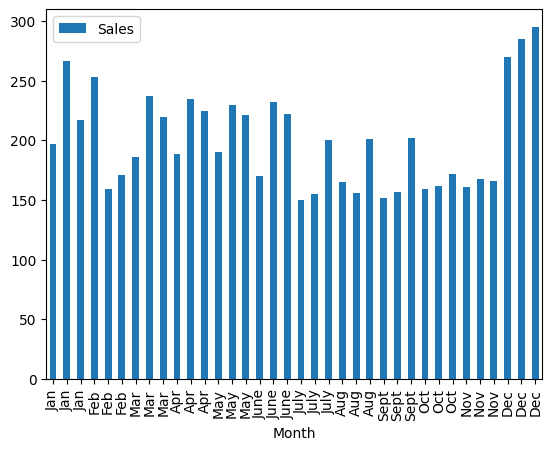

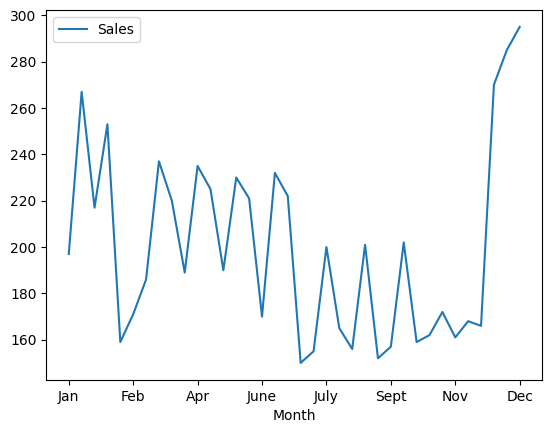

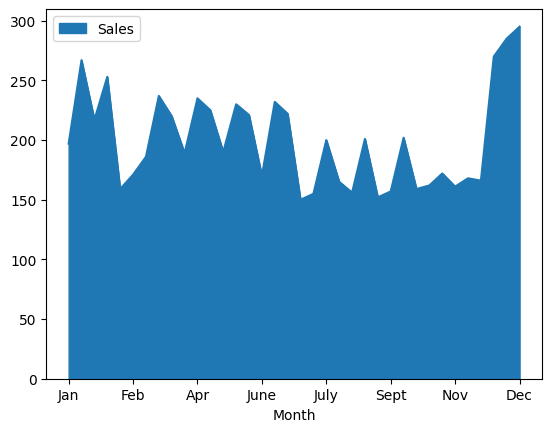

In [ ]:
sales_data_pd.plot(kind="bar", x="Month", y="Sales")
sales_data_pd.plot(kind="line", x="Month", y="Sales")
sales_data_pd.plot(kind="area", x="Month", y="Sales")

,0
Product_ID,
101,"Axes(0.125,0.11;0.775x0.77)"
102,"Axes(0.125,0.11;0.775x0.77)"
103,"Axes(0.125,0.11;0.775x0.77)"


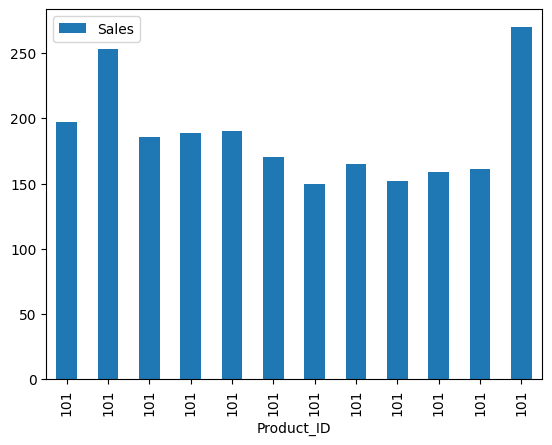

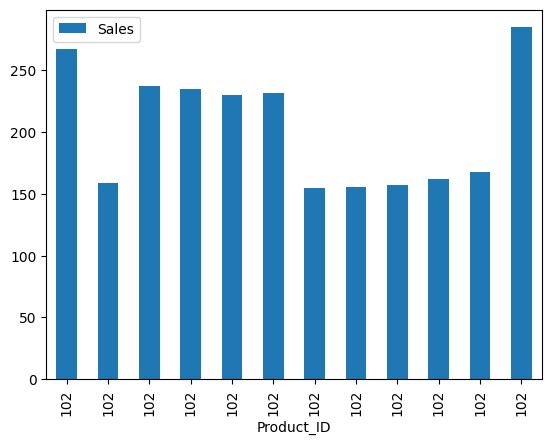

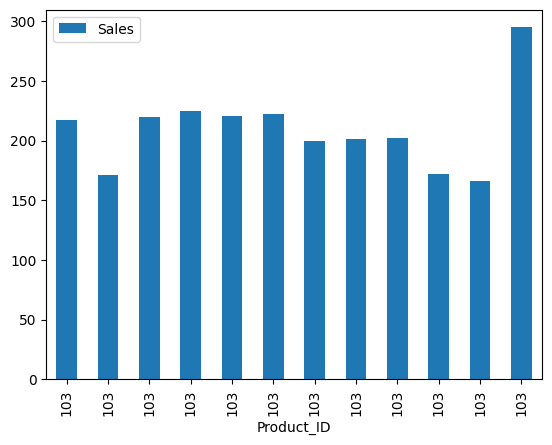

In [ ]:
sales_data_pd.groupby(by="Product_ID").plot(kind="bar", x="Product_ID", y="Sales")


# Third Pandas Polars Exercise.

## Description:
In this project, you will apply the skills you have learned in data manipulation, string operations, and data visualization using the Pandas and Matplotlib libraries. You will work on a dataset to clean, transform and visualize data to derive insights. The project will allow you to showcase your ability to handle real-world data analysis tasks.

### Dataset Loading:
- Load the provided dataset using Pandas.
- Inspect the first few rows to understand the structure of the data.

In [ ]:
import pandas as pd

# Dataset URL
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'

data = pd.read_csv(url)

In [ ]:
data

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


### String Operations:
- Suppose the dataset contains a column with string values. Perform string operations to clean or transform this column.
- You can use string methods like str.split(), str.replace(), etc.

In [ ]:
data['Year'] = data['Month'].str.split("-").str[0]

data['Month'] = data['Month'].str.split("-").str[1]



In [ ]:
data.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


### Handling Missing Values:
- Identify and handle any missing values in the dataset.

In [ ]:
data.isnull().sum()

,0
Month,0
Passengers,0
Year,0


### Data Transformation:
- Create a new column by applying a function to an existing column.

In [ ]:
# Create a new column 'Adjusted_Passengers' by applying a function
data['Adjusted_Passengers'] = data['Passengers'].apply(lambda x: x*1.1)

In [ ]:
data

,Month,Passengers,Year,Adjusted_Passengers
0,01,112,1949,123.2
1,02,118,1949,129.8
2,03,132,1949,145.2
3,04,129,1949,141.9
4,05,121,1949,133.1
...,...,...,...,...
139,08,606,1960,666.6
140,09,508,1960,558.8
141,10,461,1960,507.1
142,11,390,1960,429.0


END